# HANNA: Deskriptive Analyse

Dieses Notebook analysiert den originalen HANNA-Datensatz rein deskriptiv.

| Datensatz | Quelle | Inhalt |
|-----------|--------|--------|
| **HANNA** | GitHub (dig-team) | 1.056 Geschichten, 6 Human-Kriterien (Likert 1–5), 11 Generatoren, 96 Prompts |

**Ziel:** Verstehen, wie Generatoren sich in Human-Quality-Scores unterscheiden — als Grundlage für die Regressionsanalyse.

---
**Setup lokal:**
```bash
pip install pandas numpy matplotlib seaborn scipy
# HANNA-Datensatz:
# git clone https://github.com/dig-team/hanna-benchmark-asg
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, spearmanr
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Farbpalette (konsistent über alle Plots)
GENERATOR_COLORS = {
    'Human':        '#2ecc71',
    'BertGeneration': '#3498db',
    'CTRL':         '#9b59b6',
    'Fusion':       '#e67e22',
    'GPT':          '#e74c3c',
    'GPT-2':        '#1abc9c',
    'GPT-2 (tag)':  '#16a085',
    'HINT':         '#f39c12',
    'RoBERTa':      '#8e44ad',
    'TD-VAE':       '#2980b9',
    'XLNet':        '#c0392b',
}

HUMAN_CRITERIA = ['Relevance', 'Coherence', 'Empathy', 'Surprise', 'Engagement', 'Complexity']

print('✓ Setup abgeschlossen.')

✓ Setup abgeschlossen.


## 1. Daten laden

In [2]:
# ── Pfad anpassen ────────────────────────────────────────────────────────────
HANNA_PATH = 'data/hanna_stories_annotations.csv'
# ─────────────────────────────────────────────────────────────────────────────

ann = pd.read_csv(HANNA_PATH)
print(f'Shape: {ann.shape}')
print(f'Spalten: {list(ann.columns)}')
ann.head(3)

Shape: (3168, 15)
Spalten: ['Story ID', 'Prompt', 'Human', 'Story', 'Model', 'Relevance', 'Coherence', 'Empathy', 'Surprise', 'Engagement', 'Complexity', 'Worker ID', 'Assignment ID', 'Work time in seconds', 'Name']


,Story ID,Prompt,Human,Story,Model,Relevance,Coherence,Empathy,Surprise,Engagement,Complexity,Worker ID,Assignment ID,Work time in seconds,Name
0,0,When you die the afterlife is an arena where y...,"3,000 years have I been fighting. Every mornin...","3,000 years have I been fighting. Every mornin...",Human,4,4,3,2,4,4,A2VE5IV9OD2SK1,3X87C8JFVHIT235KQ4UTS8264I6SQJ,579.0,NaN
1,0,When you die the afterlife is an arena where y...,"3,000 years have I been fighting. Every mornin...","3,000 years have I been fighting. Every mornin...",Human,5,5,1,3,4,1,A1IZ4NX41GKU4X,3DR23U6WEGL5K0SU6D4J8W9EM9LTE7,82.0,none
2,0,When you die the afterlife is an arena where y...,"3,000 years have I been fighting. Every mornin...","3,000 years have I been fighting. Every mornin...",Human,2,2,3,2,2,3,A264NN7JBX4UDQ,3UJ1CZ6IZSW49HMM6C6QUX7F7UV5SA,273.0,none


In [3]:
# Fehlende Werte
print('Fehlende Werte pro Spalte:')
print(ann.isnull().sum())

# Generatoren
print(f'\nGeneratoren ({ann["Model"].nunique()}): {sorted(ann["Model"].unique())}')
print(f'Prompts: {ann["Prompt"].nunique()}')
print(f'Unique Story-IDs: {ann["Story ID"].nunique()}')

Fehlende Werte pro Spalte:
Story ID                  0
Prompt                    0
Human                     0
Story                     0
Model                     0
Relevance                 0
Coherence                 0
Empathy                   0
Surprise                  0
Engagement                0
Complexity                0
Worker ID                 0
Assignment ID             0
Work time in seconds      0
Name                    840
dtype: int64

Generatoren (11): ['BertGeneration', 'CTRL', 'Fusion', 'GPT', 'GPT-2', 'GPT-2 (tag)', 'HINT', 'Human', 'RoBERTa', 'TD-VAE', 'XLNet']
Prompts: 96
Unique Story-IDs: 1056


In [4]:
# Story-Level aggregieren (Mittelwert über Rater)
stories = (
    ann
    .groupby(['Story ID', 'Model', 'Prompt'])[HUMAN_CRITERIA]
    .mean()
    .reset_index()
)
stories['Overall'] = stories[HUMAN_CRITERIA].mean(axis=1)

print(f'Stories (aggregiert): {len(stories)}')
stories.head(3)

Stories (aggregiert): 1056


,Story ID,Model,Prompt,Relevance,Coherence,Empathy,Surprise,Engagement,Complexity,Overall
0,0,Human,When you die the afterlife is an arena where y...,3.666667,3.666667,2.333333,2.333333,3.333333,2.666667,3.000000
1,1,Human,A new law is enacted that erases soldiers memo...,5.000000,4.666667,4.000000,3.666667,3.666667,4.000000,4.166667
2,2,Human,A scientific study proves that all humans have...,4.666667,4.666667,4.000000,4.333333,4.000000,4.333333,4.333333


---
## 2. HANNA: Deskriptive Statistik (Story-Ebene)

### 2a. Zusammenfassung aller Kriterien

In [5]:
desc = stories[HUMAN_CRITERIA + ['Overall']].describe().T
desc['skewness'] = stories[HUMAN_CRITERIA + ['Overall']].skew()
desc['kurtosis'] = stories[HUMAN_CRITERIA + ['Overall']].kurtosis()
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Relevance,1056.0,2.625,0.955,1.0,2.000,2.667,3.333,5.000,0.376,-0.258
Coherence,1056.0,3.150,0.752,1.0,2.667,3.000,3.667,5.000,0.182,0.193
Empathy,1056.0,2.295,0.719,1.0,1.667,2.333,2.667,4.667,0.397,0.139
Surprise,1056.0,2.107,0.704,1.0,1.667,2.000,2.333,4.667,0.843,0.708
Engagement,1056.0,2.676,0.795,1.0,2.000,2.667,3.333,5.000,0.282,-0.076
Complexity,1056.0,2.452,0.788,1.0,2.000,2.333,3.000,5.000,0.423,0.170
Overall,1056.0,2.551,0.649,1.0,2.111,2.500,2.889,4.667,0.609,0.561


### 2b. Score-Verteilung pro Kriterium

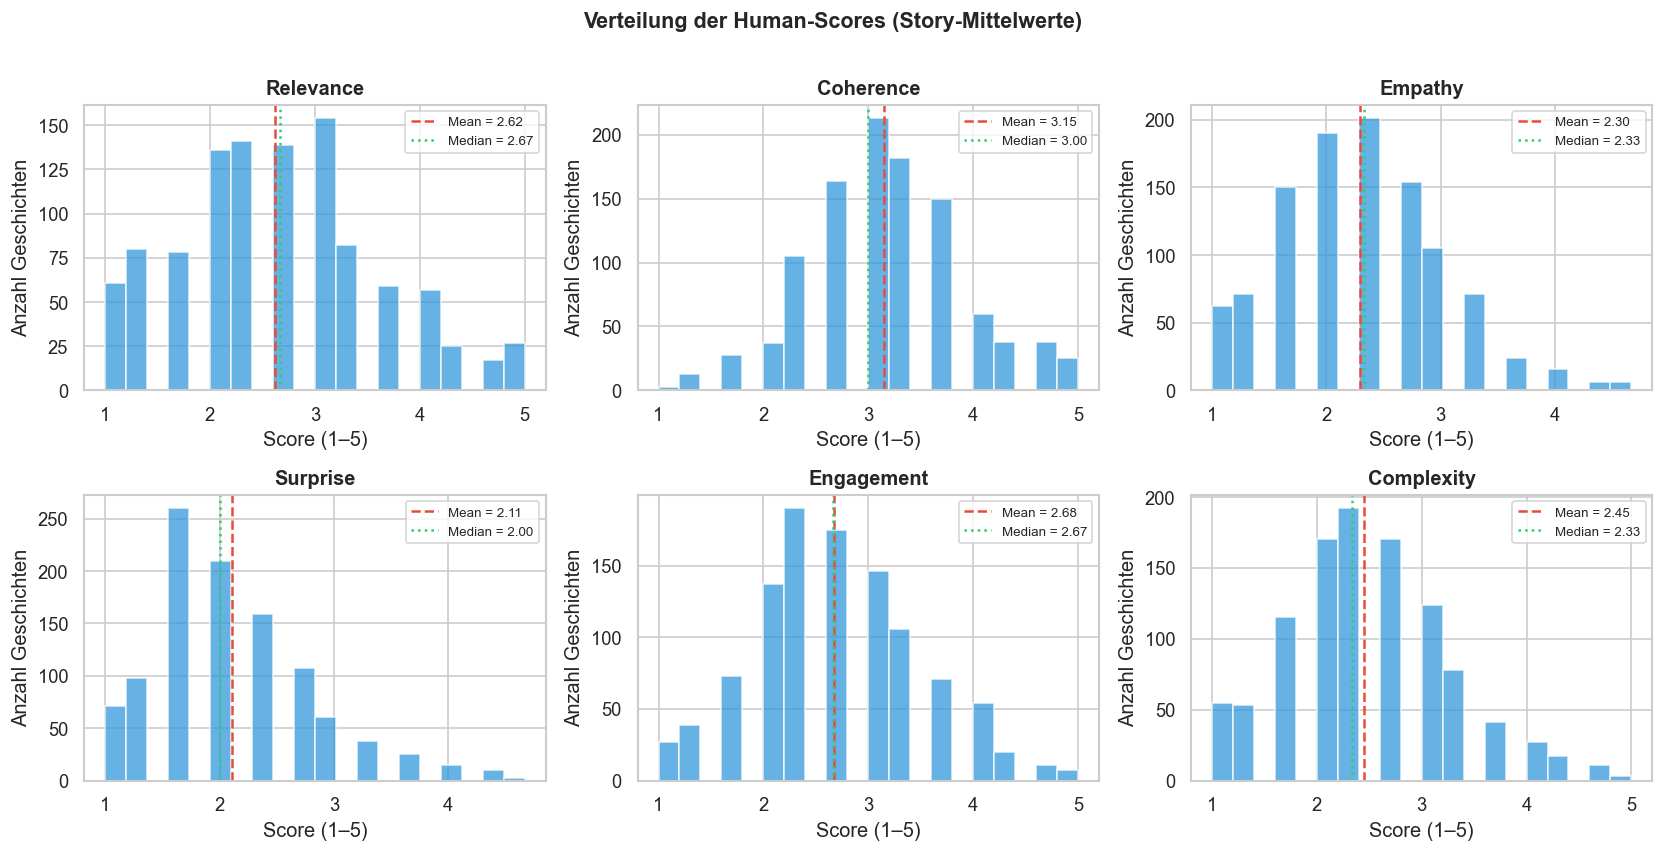

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
axes = axes.flatten()

for i, crit in enumerate(HUMAN_CRITERIA):
    ax = axes[i]
    ax.hist(stories[crit].dropna(), bins=20, color='#3498db', alpha=0.75, edgecolor='white')
    ax.axvline(stories[crit].mean(), color='#e74c3c', linestyle='--', linewidth=1.5,
               label=f'Mean = {stories[crit].mean():.2f}')
    ax.axvline(stories[crit].median(), color='#2ecc71', linestyle=':', linewidth=1.5,
               label=f'Median = {stories[crit].median():.2f}')
    ax.set_title(crit, fontweight='bold')
    ax.set_xlabel('Score (1–5)')
    ax.set_ylabel('Anzahl Geschichten')
    ax.legend(fontsize=8)

plt.suptitle('Verteilung der Human-Scores (Story-Mittelwerte)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_score_distributions.png', bbox_inches='tight')
plt.show()

### 2c. Scores nach Generator (Boxplots)

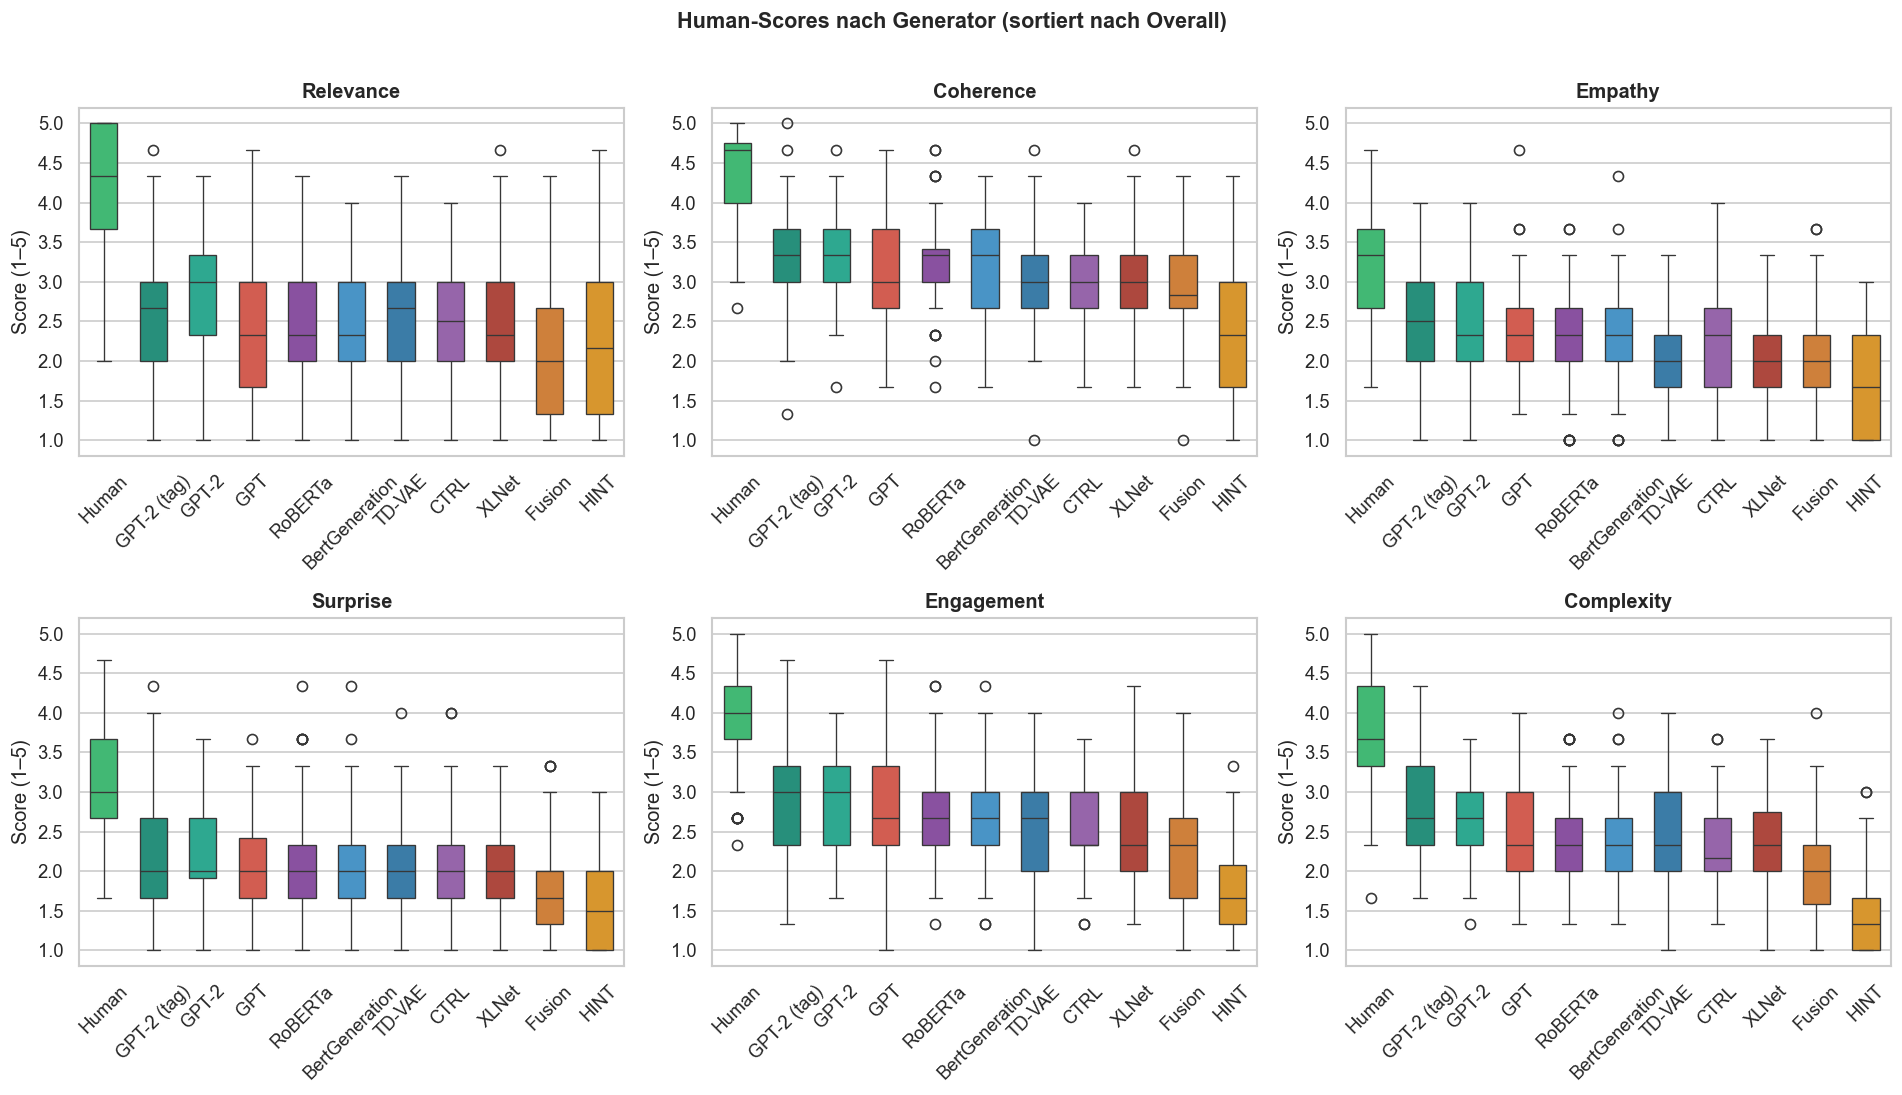

In [7]:
# Reihenfolge nach Overall-Score
gen_order = (
    stories.groupby('Model')['Overall']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, crit in enumerate(HUMAN_CRITERIA):
    ax = axes[i]
    palette = [GENERATOR_COLORS.get(g, '#7f8c8d') for g in gen_order]
    
    sns.boxplot(
        data=stories, x='Model', y=crit,
        order=gen_order, palette=palette,
        width=0.55, linewidth=0.8, ax=ax
    )
    ax.set_title(crit, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Score (1–5)')
    ax.set_ylim(0.8, 5.2)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Human-Scores nach Generator (sortiert nach Overall)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_scores_by_generator.png', bbox_inches='tight')
plt.show()

### 2d. Heatmap: Mittlere Scores pro Generator × Kriterium

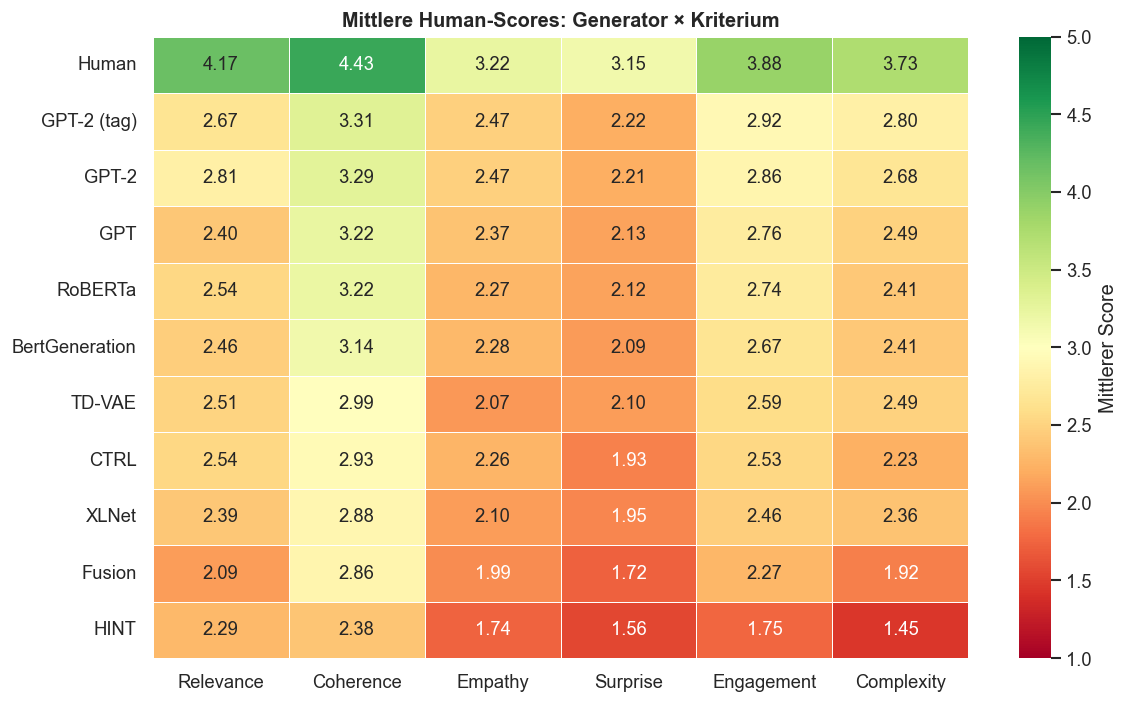

In [8]:
heatmap_data = (
    stories.groupby('Model')[HUMAN_CRITERIA]
    .mean()
    .loc[gen_order]  # sortiert nach Overall
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heatmap_data, annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=1, vmax=5,
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Mittlerer Score'}
)
ax.set_title('Mittlere Human-Scores: Generator × Kriterium', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('plot_heatmap_gen_criteria.png', bbox_inches='tight')
plt.show()

### 2e. Korrelation zwischen Kriterien (Spearman)

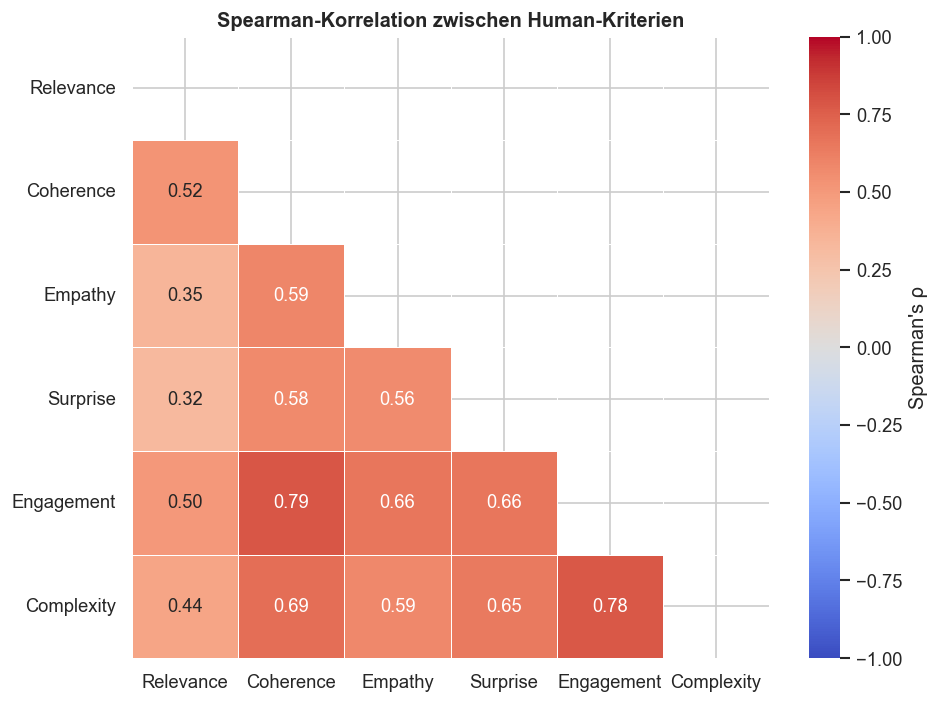

In [14]:
corr_matrix = stories[HUMAN_CRITERIA].corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'label': "Spearman's ρ"}
)
ax.set_title('Spearman-Korrelation zwischen Human-Kriterien', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_criteria_correlation.png', bbox_inches='tight')
plt.show()

### 2f. Kruskal-Wallis-Test: Unterscheiden sich Generatoren signifikant?

In [9]:
kw_results = []
for crit in HUMAN_CRITERIA + ['Overall']:
    groups = [g[crit].dropna().values for _, g in stories.groupby('Model')]
    stat, p = kruskal(*groups)
    kw_results.append({'Kriterium': crit, 'H-Statistik': round(stat, 2), 'p-Wert': round(p, 4),
                       'Signifikant (α=0.05)': '✓' if p < 0.05 else '✗'})

pd.DataFrame(kw_results).set_index('Kriterium')

,H-Statistik,p-Wert,Signifikant (α=0.05)
Kriterium,,,
Relevance,233.97,0.0,✓
Coherence,337.11,0.0,✓
Empathy,213.87,0.0,✓
Surprise,253.99,0.0,✓
Engagement,342.86,0.0,✓
Complexity,417.38,0.0,✓
Overall,394.05,0.0,✓


### 2g. Inter-Annotator Agreement (Rater-Ebene)

Wir berechnen die Streuung der Rater-Scores pro Geschichte als Maß für Agreement.

Mittlere Rater-Streuung (SD) pro Kriterium:
Relevance     1.203
Coherence     1.307
Empathy       0.922
Surprise      1.015
Engagement    0.944
Complexity    0.793

Gesamtdurchschnitt: 1.031


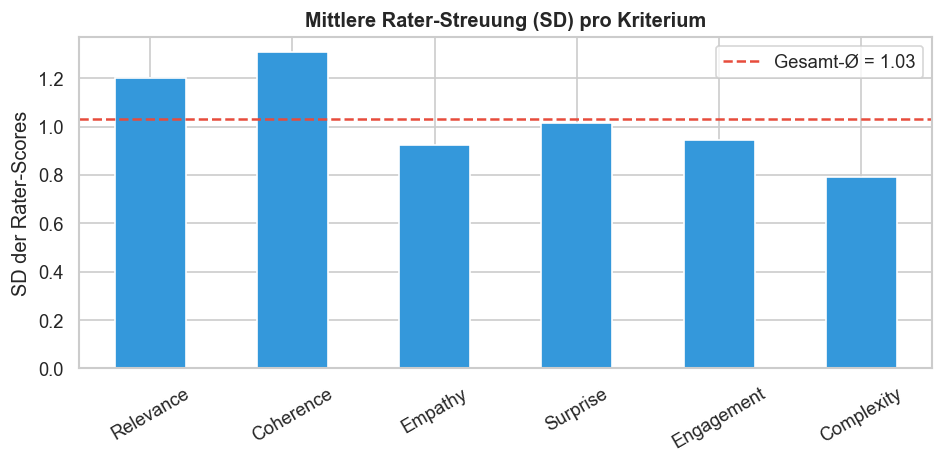

In [10]:
# Standardabweichung der Rater-Scores pro Geschichte und Kriterium
rater_std = ann.groupby('Story ID')[HUMAN_CRITERIA].std().reset_index()
rater_std_mean = rater_std[HUMAN_CRITERIA].mean()

print('Mittlere Rater-Streuung (SD) pro Kriterium:')
print(rater_std_mean.round(3).to_string())
print(f'\nGesamtdurchschnitt: {rater_std_mean.mean():.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
rater_std_mean.plot(kind='bar', color='#3498db', ax=ax, edgecolor='white')
ax.axhline(rater_std_mean.mean(), color='#e74c3c', linestyle='--', label=f'Gesamt-Ø = {rater_std_mean.mean():.2f}')
ax.set_title('Mittlere Rater-Streuung (SD) pro Kriterium', fontweight='bold')
ax.set_ylabel('SD der Rater-Scores')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig('plot_rater_agreement.png', bbox_inches='tight')
plt.show()

---
## 3. Prompt-Ebene: Variabilität der Qualitätsurteile

Wie stark variiert der Overall-Score zwischen Generatoren pro Prompt?

In [11]:
# Wie stark variiert Overall-Score zwischen Generatoren pro Prompt?
prompt_var = (
    stories.groupby('Prompt')['Overall']
    .agg(['mean', 'std', 'min', 'max'])
    .rename(columns={'mean': 'Ø Score', 'std': 'SD', 'min': 'Min', 'max': 'Max'})
    .assign(range=lambda x: x['Max'] - x['Min'])
)

print('Prompts mit höchster Varianz (Top 10):')
print(prompt_var.sort_values('SD', ascending=False).head(10).round(3).to_string())

Prompts mit höchster Varianz (Top 10):
                                                                                                                                                                                                                                                                                                      Ø Score     SD    Min    Max  range
Prompt                                                                                                                                                                                                                                                                                                                                   
A scientific study proves that all humans have been breathing a mind-altering gas from birth. It has been in the air since the beginning of recorded time. People have been in a constant state of being high. Until now. Specialised gas masks are handed out and people have begun to act strange.    2.636

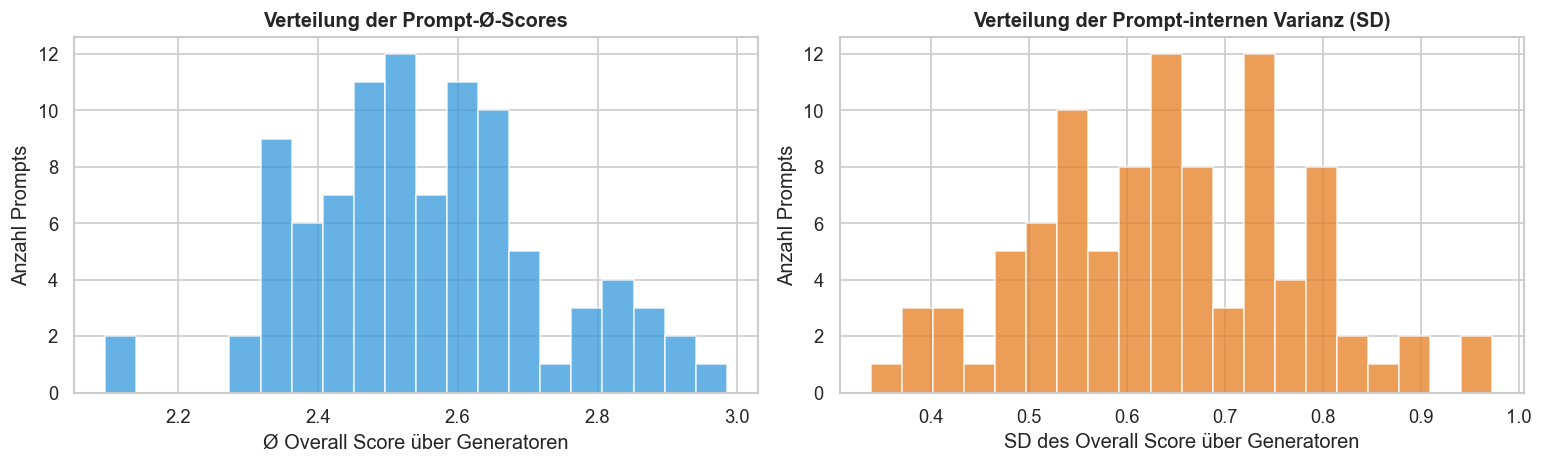

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(prompt_var['Ø Score'], bins=20, color='#3498db', alpha=0.75, edgecolor='white')
axes[0].set_title('Verteilung der Prompt-Ø-Scores', fontweight='bold')
axes[0].set_xlabel('Ø Overall Score über Generatoren')
axes[0].set_ylabel('Anzahl Prompts')

axes[1].hist(prompt_var['SD'], bins=20, color='#e67e22', alpha=0.75, edgecolor='white')
axes[1].set_title('Verteilung der Prompt-internen Varianz (SD)', fontweight='bold')
axes[1].set_xlabel('SD des Overall Score über Generatoren')
axes[1].set_ylabel('Anzahl Prompts')

plt.tight_layout()
plt.savefig('plot_prompt_variability.png', bbox_inches='tight')
plt.show()

---
## 4. Zusammenfassung der Befunde

In [13]:
print('=' * 60)
print('HANNA DESKRIPTIVE ANALYSE — ZUSAMMENFASSUNG')
print('=' * 60)

print(f'\n[Datensatz]')
print(f'  Geschichten (aggregiert): {len(stories)}')
print(f'  Prompts: {stories["Prompt"].nunique()}')
print(f'  Generatoren: {stories["Model"].nunique()}')

print(f'\n[Human-Scores]')
for crit in HUMAN_CRITERIA:
    m, s = stories[crit].mean(), stories[crit].std()
    print(f'  {crit:<12}: M={m:.2f}, SD={s:.2f}')

print(f'\n[Generatoren-Ranking nach Overall]')
ranking = stories.groupby('Model')['Overall'].mean().sort_values(ascending=False)
for gen, score in ranking.items():
    print(f'  {gen:<20}: {score:.2f}')

print('=' * 60)

HANNA DESKRIPTIVE ANALYSE — ZUSAMMENFASSUNG

[Datensatz]
  Geschichten (aggregiert): 1056
  Prompts: 96
  Generatoren: 11

[Human-Scores]
  Relevance   : M=2.62, SD=0.96
  Coherence   : M=3.15, SD=0.75
  Empathy     : M=2.30, SD=0.72
  Surprise    : M=2.11, SD=0.70
  Engagement  : M=2.68, SD=0.80
  Complexity  : M=2.45, SD=0.79

[Generatoren-Ranking nach Overall]
  Human               : 3.76
  GPT-2 (tag)         : 2.73
  GPT-2               : 2.72
  GPT                 : 2.56
  RoBERTa             : 2.55
  BertGeneration      : 2.51
  TD-VAE              : 2.46
  CTRL                : 2.40
  XLNet               : 2.36
  Fusion              : 2.14
  HINT                : 1.86


---
*Nächster Schritt: Diversity-Berechnung (D_sem, D_lex, D_syn, D_disc) für alle HANNA-Geschichten als Grundlage für die Regressionsanalyse.*